In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
import lightning as L
import yaml
import lightning_scripts.lightning_classifier_matched_speech_in_noise as lightning 
import importlib
import torch
from lightning_scripts import jsinV3DataLoader_precombined_batched 
import pandas as pd 

In [2]:
torch.set_float32_matmul_precision = 'medium'

In [3]:
###
config_path = "model_configs/word_speaker_audioset_resnet18_MatchedSpeechInNoiseDatasetBatched.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
config['num_workers'] = 2
config['hparas']['batch_size'] = 32
config['hparas']['lr'] = 1e-1
# config['data']['overfit'] = True

In [ ]:
importlib.reload(lightning)
LitWordAudioSetModel = lightning.LitWordAudioSetModel
from lightning.pytorch.loggers import WandbLogger

model = LitWordAudioSetModel(config)


In [7]:
model.model

ModelWithFrontEnd(
  (front_end): AudioToAudioRepresentation(
    (rep): AudioToCochleagram(
      (envelope_extraction): HilbertEnvelopeExtraction()
      (downsampling_op): SincWithKaiserWindow()
      (Cochleagram): Cochleagram(
        (compute_subbands): ComputeSubbands()
        (envelope_extraction): HilbertEnvelopeExtraction()
        (downsampling): SincWithKaiserWindow()
      )
    )
    (compression): ClippedGradPower(
      (compression_function): ClippedGradPowerCompression()
    )
  )
  (model): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): SequentialWithArgs(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNo

### Try Lightning Module

In [4]:

wandb_logger = WandbLogger(project="dev_matched_supervised")
wandb_logger.watch(model.model, log="all", log_freq=5)


trainer = L.Trainer(
    # limit_train_batches=5,
    # limit_val_batches=0,
    max_epochs=config['hparas']['epochs'],
    # strategy='ddp_notebook',
    # gradient_clip_val=1,
    # overfit_batches=.001,
    logger=wandb_logger,
    devices=1)

trainer.fit(model)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: iangriffith (iangriffith-harvard-university). Use `wandb login --relogin` to force relogin


wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3. ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type                       | Params | Mode 
-----------------------------------------------------------------------
0 | audio_rep       | AudioToAudioRepresentation | 0      | train
1 | model           | ModelWithFrontEnd          | 12.1 M | train
2 | multi_task_loss | jsinV3_multi_task_loss     | 0      | train
3 | train_accuracy  | ModuleDict                 | 0      | train
4 | val_accura

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

24149

Short file30186
Short file


Training: |          | 0/? [00:00<?, ?it/s]

31736
Short file
25208
Short file
14063
Short file
26834
Short file
27864
Short file
19403
Short file



Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

### Make sure dataset labels match examples

In [5]:
config['data']['target_keys']

['signal/word_int', 'signal/speaker_int', 'noise/labels_int']

In [6]:
config['data']['val_noise_h5_path']

'/mnt/home/jfeather/ceph/data/training_datasets_audio/audioset_dataframes/sr20000/cullLabels_silence/sr20000_balanced_train_segments_raw_exclude_speech_and_only_music_maxZerosPercent10.pdh5'

In [5]:
importlib.reload(jsinV3DataLoader_precombined_batched)

### Write collate function 
def collate_fn(batch):
    output_11, output_12, output_21, output_22, target_11, target_12, target_21, target_22 = batch[0]
    audio = torch.vstack([output_11, output_12, output_21, output_22]).unsqueeze(1)
    # combine labels: each target is dict for each key, stack the values 
    labels = {}
    for label_key in target_11.keys():
        labels[label_key] = torch.concat([label_set[label_key] for label_set in [target_11, target_12, target_21, target_22]])
    return audio, labels
            

batch_size = 4

MatchedSpeechInNoiseDatasetBatched = jsinV3DataLoader_precombined_batched.MatchedSpeechInNoiseDatasetBatched
dataset = MatchedSpeechInNoiseDatasetBatched(config['data']['speech_h5_path'],
                                             config['data']['noise_h5_path'],
                                             target_keys=config['data']['target_keys'],
                                             batch_size=batch_size)

# audio, labels = collate_fn(dataset[0])
dataloader = torch.utils.data.DataLoader(dataset, collate_fn=collate_fn)

In [6]:
from tqdm import tqdm

In [15]:
noises = dataset.noise_files['ndarray_data']['signal'][0:10]

In [16]:
noise = np.array([noise_eg for noise_eg in noises if noise_eg.shape[0] >= 40_000], dtype="object")


10

array([array([-3303.60803675, -4562.89993706, -3836.28709929, ...,
               3065.60890416,  2736.50989661,  1875.91061367])    ,
       array([ -5966.79543486, -11085.56568072,  -9797.58642499, ...,
                 652.69789982,  -1095.15900075,   -393.12907332])    ],
      dtype=object)

In [16]:
dataset.noise_metadata[dataset.noise_metadata.signal_length > 40_000].index.values

array([     0,      1,      2, ..., 718606, 718607, 718608])

wandb: 🚀 View run deep-water-11 at: https://wandb.ai/iangriffith-harvard-university/dev_matched_supervised/runs/vr9ajkk8


In [9]:
n_examples = len(dataset.noise_files['ndarray_data']['signal'])
bad_ixs = np.zeros(n_examples)

for i in tqdm(range(n_examples)):
    if dataset.noise_files['ndarray_data']['signal'][i].shape[0] < 40_000:
        print(f"Short file at ix {i}")
        bad_ixs[i] = i 
   

  0%|          | 3375/718625 [00:13<47:28, 251.08it/s]  


KeyboardInterrupt: 

In [12]:
Audio(dataset.speech_files['ndarray_data']['signal'][230355], rate=20000)

In [ ]:
range(examples, step=)

718625

In [53]:
n_examples = len(dataset.noise_files['ndarray_data']['signal'])
bad_ixs = []

chunk_size = 20
for i in tqdm(range(0, n_examples, chunk_size)):
    sums = [s.sum() for s in dataset.noise_files['ndarray_data']['signal'][i:i+chunk_size]]
    is_nan = np.argwhere(np.isnan(sums))
    is_sil = np.argwhere(sums == 0)
    if len(is_nan) > 0 or len(is_sil) > 0:
        print(f"Bad ixs at {i}")
        bad_ixs.append(is_nan)
        bad_ixs.append(is_sil)

  3%|▎         | 941/35932 [02:18<1:25:50,  6.79it/s]


KeyboardInterrupt: 

In [ ]:
ixs = np.argwhere(np.isnan([s.sum() for s in sound]))


0

In [16]:
len(dataset.speech_files['ndarray_data']['signal'])

230357

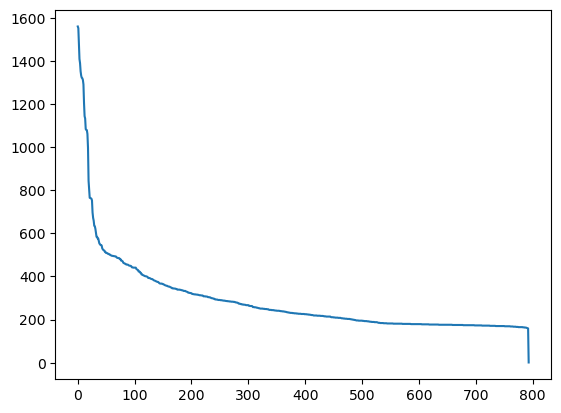

In [9]:
plt.plot(dataset.speech_metadata.word_int.value_counts().values)

In [11]:
labels[ 'noise/labels_int'][1].shape

torch.Size([517])

In [12]:
class_map, full_map = dataset.class_map()

In [12]:
## Check word balance labeling is correct across batches 



SR = 20_000
pair_ix = 1
offset = batch_size * 2 
word_1 = class_map[int(labels['signal/word_int'][pair_ix])]

print(word_1)
display(Audio(audio[pair_ix], rate=SR))
display(Audio(audio[pair_ix+batch_size], rate=SR))
word_2 = class_map[int(labels['signal/word_int'][pair_ix+offset])]
print(word_2)
display(Audio(audio[pair_ix+offset], rate=SR))
display(Audio(audio[pair_ix+offset+batch_size], rate=SR))

three


already


In [13]:
#### Make sure background pairing is correct 

## Check word balance labeling is correct across batches 

get_word = lambda ix: class_map[int(labels['signal/word_int'][ix])]
get_noises = lambda ix: labels['noise/labels_int'][ix].argwhere().flatten()

SR = 20_000
pair_ix = 4
offset = batch_size * 2 
print("Background 1")
print(f"\t word: {get_word(pair_ix)}")
print(f"\t noises: {get_noises(pair_ix)}")
display(Audio(audio[pair_ix], rate=SR))
print(f"\t word: {get_word(pair_ix+offset)}")
print(f"\t noises: {get_noises(pair_ix+offset)}")
display(Audio(audio[pair_ix+offset], rate=SR))

print("Background 2")
print(f"\t word: {get_word(pair_ix+1)}")
print(f"\t noises: {get_noises(pair_ix+1)}")
display(Audio(audio[pair_ix+1], rate=SR))
print(f"\t word: {get_word(pair_ix+1+offset)}")
print(f"\t noises: {get_noises(pair_ix+1+offset)}")
display(Audio(audio[pair_ix+1+offset], rate=SR))


Background 1
	 word: eighty
	 noises: tensor([16, 95])


	 word: operation
	 noises: tensor([16, 95])


Background 2
	 word: three
	 noises: tensor([188, 378])


	 word: already
	 noises: tensor([188, 378])


In [14]:
## Make sure the labels actually make sense for each element in a batch 

for ix, aud in enumerate(audio):
    print(f"word: {get_word(ix)}")
    print(f"noises: {get_noises(ix)}")
    display(Audio(aud, rate=SR))
        


word: eighty
noises: tensor([147, 211, 410, 454])


word: three
noises: tensor([113, 244, 366])


word: would
noises: tensor([113])


word: activity
noises: tensor([379, 511])


word: eighty
noises: tensor([16, 95])


...

word: introduced
noises: tensor([379, 511])


word: operation
noises: tensor([16, 95])


word: already
noises: tensor([188, 378])


word: results
noises: tensor([149, 379])


word: introduced
noises: tensor([ 59, 162, 229])
